--- STARTING IN-DEPTH VISUALIZATIONS FOR PARIS ---
--- LOADING AGGREGATED DATA ---


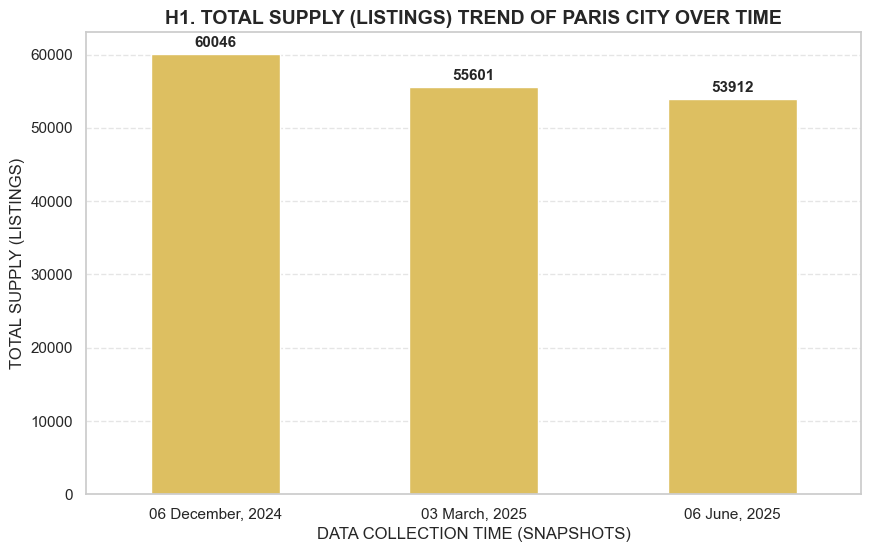

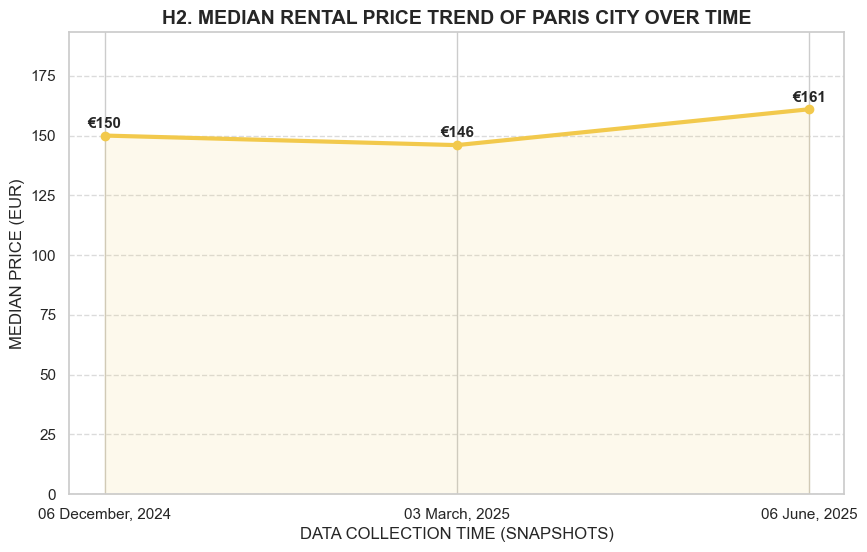

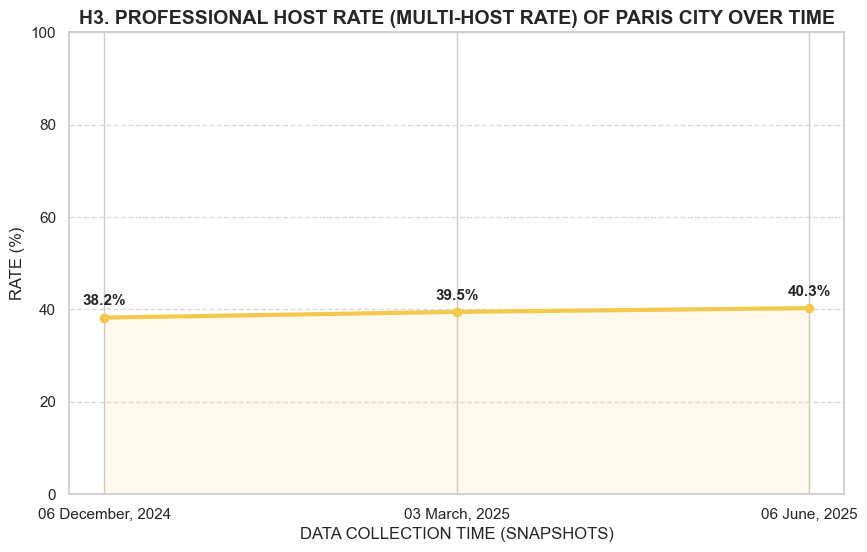

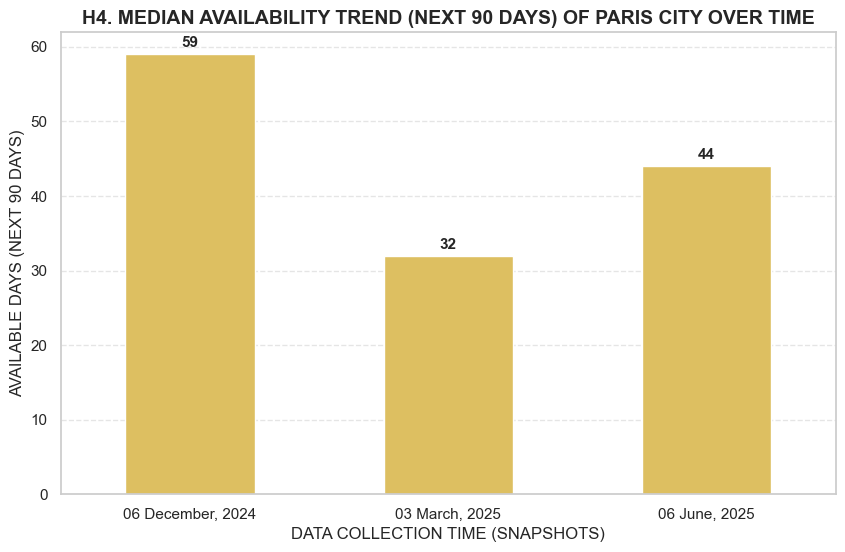

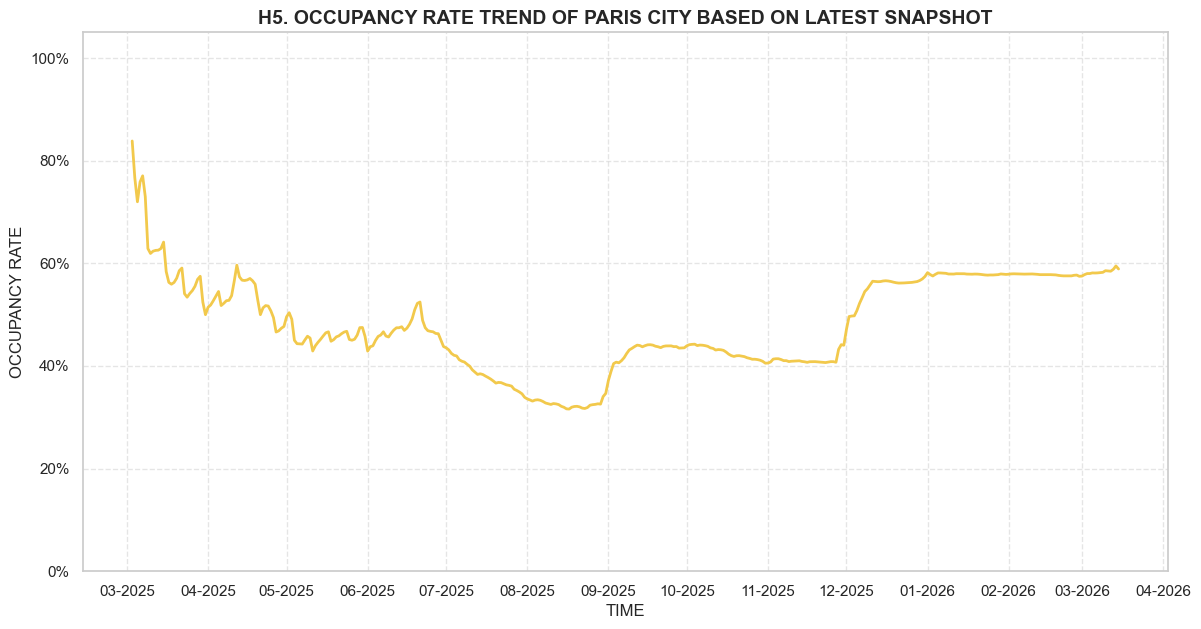

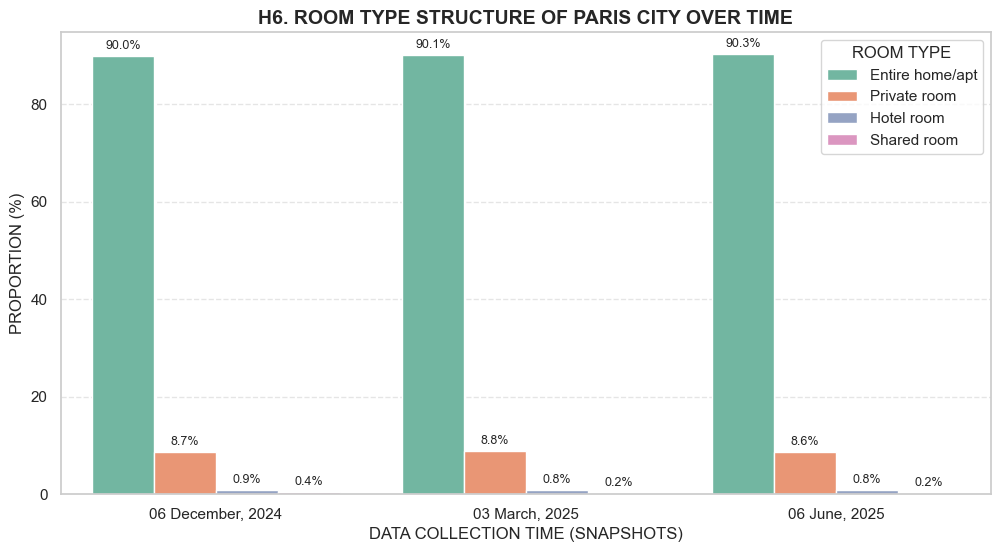

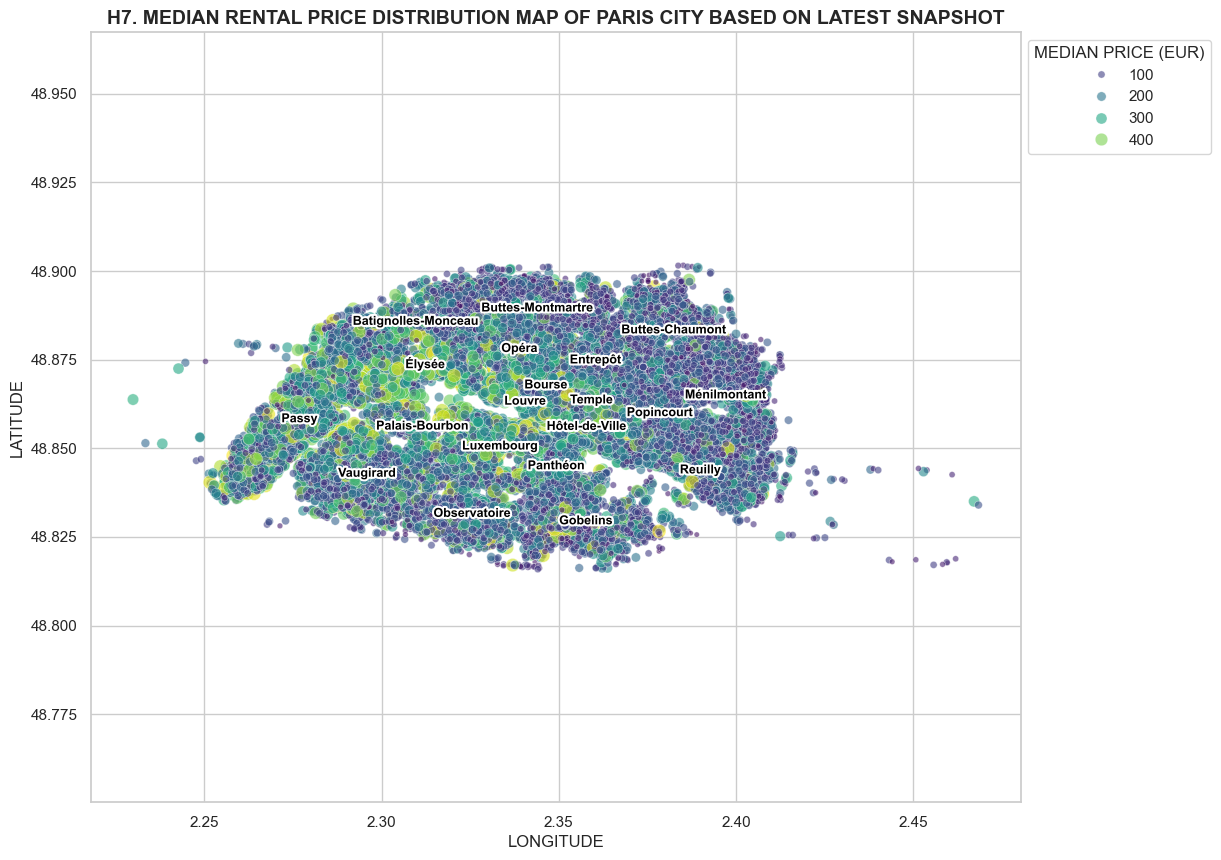

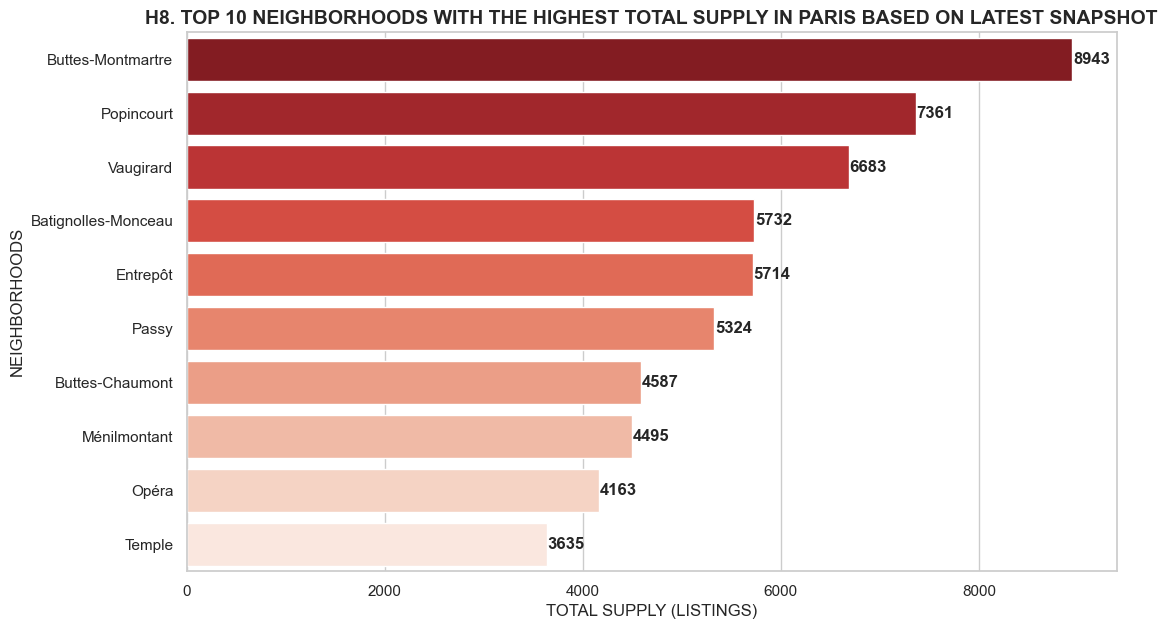

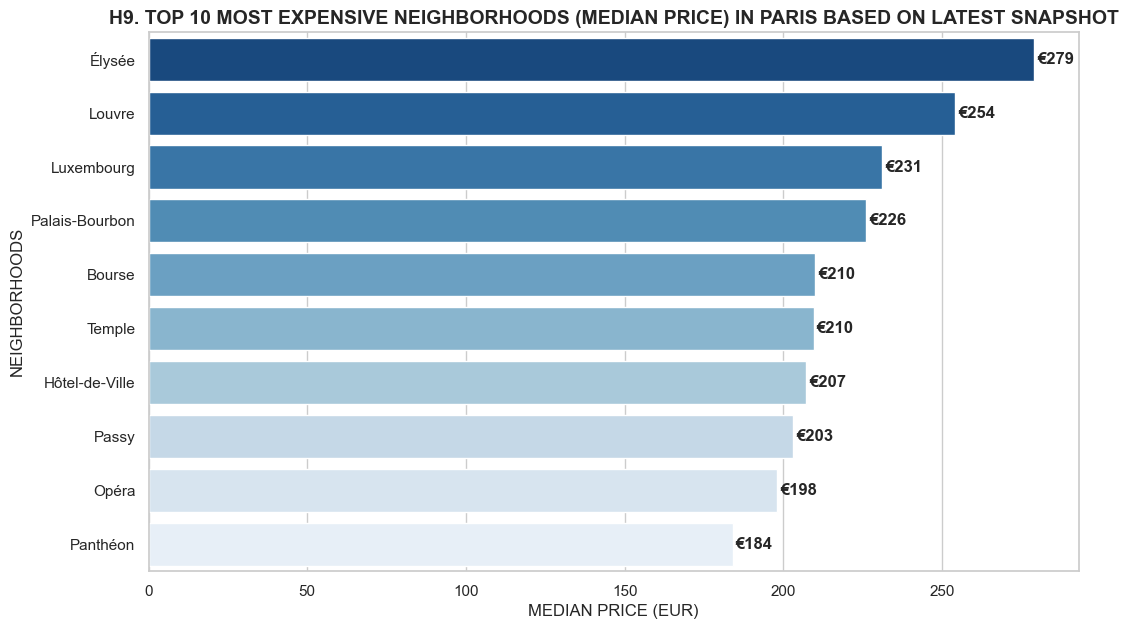

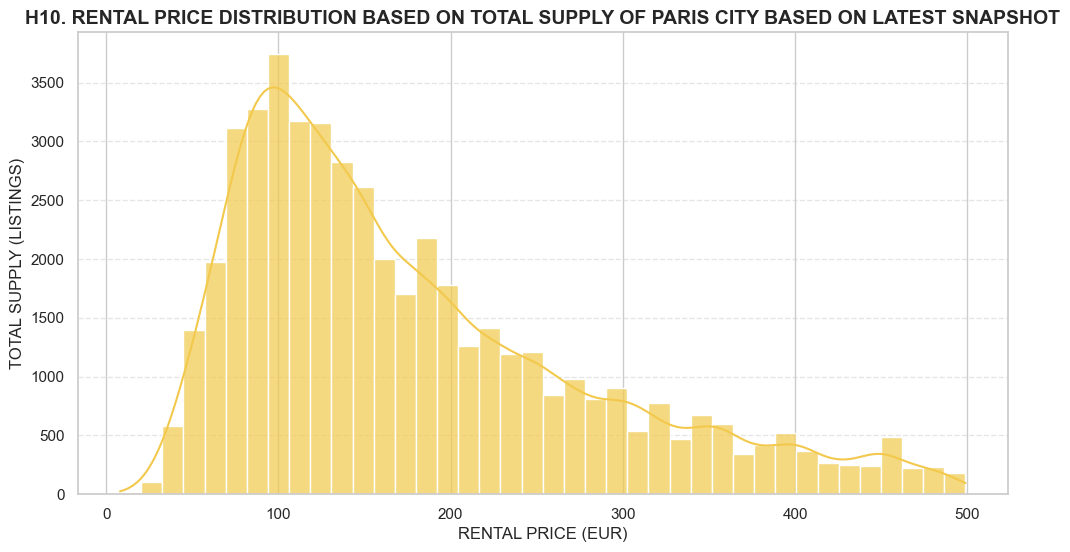

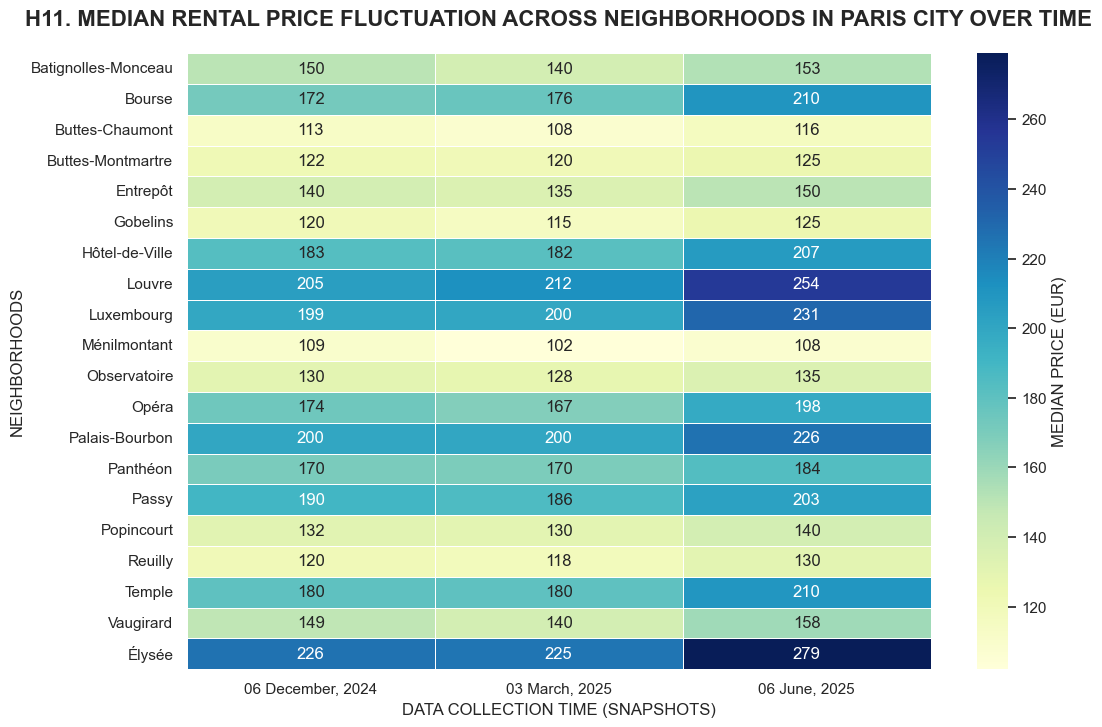

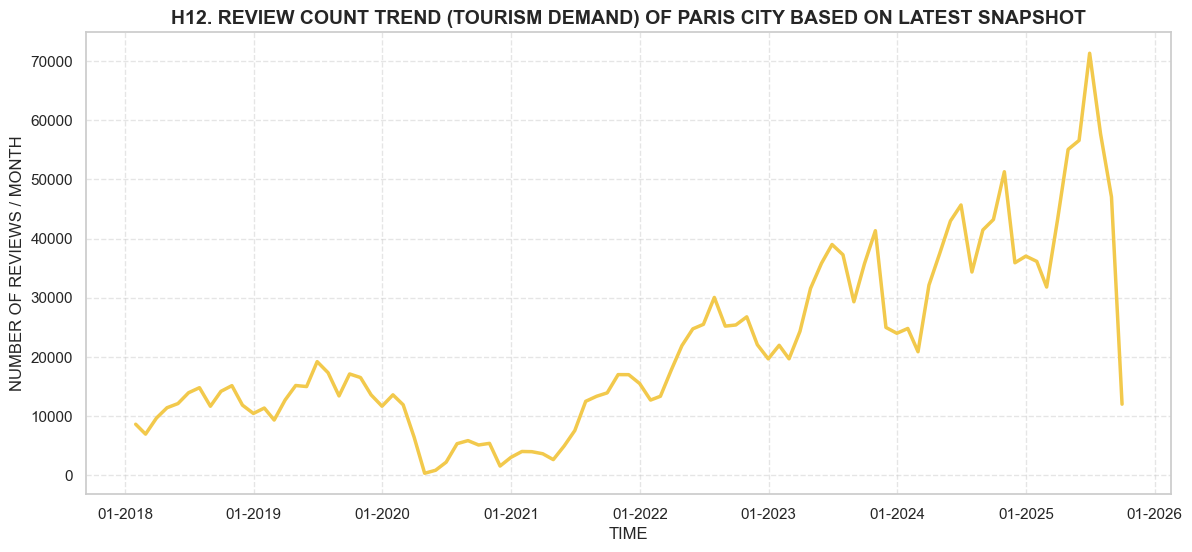

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as PathEffects
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# --- 1. SETUP ---
sns.set_theme(style="whitegrid")
BASE_DIR = '..'
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed', 'paris')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
CITY_SUFFIX = 'paris'

print("--- STARTING IN-DEPTH VISUALIZATIONS FOR PARIS ---")

# --- 2. LOAD KPI DATA ---
try:
    kpi_supply = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_summary_general_{CITY_SUFFIX}.csv'))
    kpi_room = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_room_type_{CITY_SUFFIX}.csv'))
    kpi_season = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_seasonality_{CITY_SUFFIX}.csv'))
    # Load 2 new files
    kpi_neigh = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_neighbourhood_{CITY_SUFFIX}.csv'))
    kpi_review = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_reviews_trend_{CITY_SUFFIX}.csv'))
    
    # Sort by time
    kpi_supply['dt'] = pd.to_datetime(kpi_supply['snapshot_date'], errors='coerce')
    kpi_supply = kpi_supply.sort_values('dt')
    print("--- LOADING AGGREGATED DATA ---")
except FileNotFoundError as e:
    print(f" Missing KPI file: {e}")
    kpi_supply = pd.DataFrame(); kpi_room = pd.DataFrame(); kpi_season = pd.DataFrame()
    kpi_neigh = pd.DataFrame(); kpi_review = pd.DataFrame()


# --- 3. LOAD DETAILED DATA  ---
from datetime import datetime

def parse_snapshot_name(name):
    try:
        return datetime.strptime(name.strip(), "%d %B, %Y")
    except:
        return None

# Get snapshot list (directories only)
snapshot_dirs = [
    d for d in os.listdir(PROCESSED_DIR)
    if os.path.isdir(os.path.join(PROCESSED_DIR, d))
]

# Parse & sort (newest -> oldest)
parsed = [(d, parse_snapshot_name(d)) for d in snapshot_dirs]
parsed = [p for p in parsed if p[1] is not None]
snapshots = [name for name, dt in sorted(parsed, key=lambda x: x[1], reverse=True)]



# Function to check snapshot quality
def is_valid_snapshot(df, require_geo_for_map=False, min_rows=50):
    # Has data
    if df is None or df.empty:
        return False, "empty"
    # Minimum rows
    if len(df) < min_rows:
        return False, f"too_few_rows ({len(df)} < {min_rows})"
    # Has price_numeric column
    if 'price_numeric' not in df.columns:
        return False, "missing_price_numeric"
    # Convert price to numeric (remove strange characters if any)
    try:
        # if already numeric, this is fine
        price_series = pd.to_numeric(df['price_numeric'], errors='coerce')
    except Exception as e:
        return False, f"price_coerce_error: {e}"
    non_null = price_series.notna().sum()
    non_null_ratio = non_null / len(df)
    if non_null_ratio < 0.6:  # at least 60% must be numeric
        return False, f"price_too_many_missing ({non_null_ratio:.2f})"
    # Price is in a reasonable range (median)
    med = price_series.dropna().median()
    if pd.isna(med):
        return False, "price_median_na"
    if not (3 <= med <= 5000):  # adjust bounds if needed
        return False, f"price_median_out_of_range (€{med:.0f})"
    # Check latitude/longitude if using map
    if require_geo_for_map:
        if ('latitude' not in df.columns) or ('longitude' not in df.columns):
            return False, "missing_geo_cols"
        lat_valid = df['latitude'].notna().sum() / len(df)
        lon_valid = df['longitude'].notna().sum() / len(df)
        if lat_valid < 0.5 or lon_valid < 0.5:
            return False, "too_many_missing_geo"
    return True, "ok"

# Find valid snapshot (newest -> oldest)
df_detail = pd.DataFrame()
LATEST_SNAPSHOT = None
reasons = {}

for snap in snapshots:
    file_path = os.path.join(PROCESSED_DIR, snap, 'listings_processed.csv')
    if not os.path.exists(file_path):
        reasons[snap] = "file_not_found"
        continue
    try:
        temp = pd.read_csv(file_path, low_memory=False)
    except Exception as e:
        reasons[snap] = f"read_error: {e}"
        continue

    valid, reason = is_valid_snapshot(temp, require_geo_for_map=False, min_rows=50)
    reasons[snap] = reason
    if valid:
        df_detail = temp.copy()
        LATEST_SNAPSHOT = snap
        
        break
    else:
        
        continue

# If no good snapshot found, try relaxing conditions (smaller min_rows, still need price_numeric)
if LATEST_SNAPSHOT is None:
    
    for snap in snapshots:
        if reasons.get(snap) == "file_not_found":
            continue
        file_path = os.path.join(PROCESSED_DIR, snap, 'listings_processed.csv')
        try:
            temp = pd.read_csv(file_path, low_memory=False)
        except:
            continue
        valid, reason = is_valid_snapshot(temp, require_geo_for_map=False, min_rows=10)
        if valid:
            df_detail = temp.copy()
            LATEST_SNAPSHOT = snap
           
            break

if LATEST_SNAPSHOT is None:
    for s, r in reasons.items():
        print(f"  - {s}: {r}")



# --- CLEAN KPI SUPPLY BEFORE PLOTTING ---
kpi_supply_clean = kpi_supply.copy()

# remove rows with no listings or anomalies
kpi_supply_clean = kpi_supply_clean[
    (kpi_supply_clean['total_listings'].notna()) &
    (kpi_supply_clean['total_listings'] > 0)
]

# remove snapshots with unparseable dates
kpi_supply_clean = kpi_supply_clean[
    kpi_supply_clean['dt'].notna()
]



# --- 4. PLOTTING CHARTS ---

# === H1: Supply Trend (Bar Chart) ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    ax1 = sns.barplot(data=kpi_supply_clean, x='snapshot_date', y='total_listings', color='#F2C94C', width=0.5)
    plt.title('H1. TOTAL SUPPLY (LISTINGS) TREND OF PARIS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax1.containers: ax1.bar_label(i, padding=3, fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_01_supply.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H2: Price Trend (Line/Area Chart) ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(kpi_supply['snapshot_date'], kpi_supply['median_price'], marker='o', linewidth=3, color='#F2C94C')
    plt.fill_between(kpi_supply['snapshot_date'], kpi_supply['median_price'], color='#F2C94C', alpha=0.1)
    plt.title('H2. MEDIAN RENTAL PRICE TREND OF PARIS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('MEDIAN PRICE (EUR)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for x, y in zip(kpi_supply['snapshot_date'], kpi_supply['median_price']):
        plt.text(x, y + 2, f"€{y:.0f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.ylim(bottom=0, top=kpi_supply['median_price'].max()*1.2)
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_02_price.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    

# === H3: PROFESSIONAL HOST RATE TREND (MULTI-HOST RATE) ===
if not kpi_supply.empty and 'multi_host_rate' in kpi_supply.columns:
    
    # Filter out snapshots with 0 values
    df_mhr = kpi_supply[kpi_supply['multi_host_rate'] > 0].copy()

    plt.figure(figsize=(10, 6))
    plt.plot(df_mhr['snapshot_date'], df_mhr['multi_host_rate'], marker='o', linewidth=3, color='#F2C94C')
    plt.fill_between(df_mhr['snapshot_date'], df_mhr['multi_host_rate'], color='#F2C94C', alpha=0.1)

    plt.title(f'H3. PROFESSIONAL HOST RATE (MULTI-HOST RATE) OF {CITY_SUFFIX.upper()} CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('RATE (%)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, 100)

    # Display % values
    for x, y in zip(df_mhr['snapshot_date'], df_mhr['multi_host_rate']):
        plt.text(x, y + 2, f"{y:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_03_multi_host.pdf'), format='pdf', bbox_inches='tight')

    plt.show()




# === H4: MEDIAN AVAILABILITY TREND (AVAILABILITY 90) ===
if not kpi_supply.empty and 'median_avail_90' in kpi_supply.columns:
    
    # Filter out snapshots with 0 values
    df_avail = kpi_supply[kpi_supply['median_avail_90'] > 0].copy()

    plt.figure(figsize=(10, 6))
    ax12 = sns.barplot(
        data=df_avail,
        x='snapshot_date',
        y='median_avail_90',
        color='#F2C94C',
        width=0.5
    )
    
    plt.title(
        f'H4. MEDIAN AVAILABILITY TREND (NEXT 90 DAYS) '
        f'OF {CITY_SUFFIX.upper()} CITY OVER TIME',
        fontsize=14, fontweight='bold'
    )
    plt.ylabel('AVAILABLE DAYS (NEXT 90 DAYS)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Label
    for container in ax12.containers:
        ax12.bar_label(container, padding=3, fontsize=11, fontweight='bold')
        
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_04_availability.pdf'),
                format='pdf', bbox_inches='tight')
    plt.show()



# === H5: Occupancy Rate Trend (Line Chart) ===
if not kpi_season.empty:
    df_h5 = kpi_season.copy()
    # Convert dates
    df_h5['date_dt'] = pd.to_datetime(df_h5['date'], errors='coerce')
    df_h5['snapshot_dt'] = pd.to_datetime(df_h5['snapshot_date'], errors='coerce')
    
    # Get data from the LATEST snapshot
    latest_snap_dt = df_h5['snapshot_dt'].max()
    df_final_h5 = df_h5[df_h5['snapshot_dt'] == latest_snap_dt].sort_values('date_dt')

    if not df_final_h5.empty:
        plt.figure(figsize=(14, 7))
        sns.lineplot(data=df_final_h5, x='date_dt', y='occupancy_rate', color='#F2C94C', linewidth=2)
        
        # Format axes
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

        plt.title(f'H5. OCCUPANCY RATE TREND OF PARIS CITY BASED ON LATEST SNAPSHOT', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('OCCUPANCY RATE')
        plt.xlabel('TIME')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(0, 1.05)
       
        
        plt.savefig(os.path.join(FIGURES_DIR, 'paris_05_occupancy.pdf'), format='pdf', bbox_inches='tight')
        plt.show()
        
    else:
        print("   ! No occupancy data for the latest snapshot.")
else:
    print("   ! No seasonality data available.")


# === H6: Room Type Structure (Grouped Bar) ===
if not kpi_room.empty:
    plt.figure(figsize=(12, 6))
    kpi_room['dt'] = pd.to_datetime(kpi_room['snapshot_date'], errors='coerce')
    kpi_room = kpi_room.sort_values('dt')
    
    ax3 = sns.barplot(data=kpi_room, x='snapshot_date', y='percentage', hue='room_type', palette='Set2')
    plt.title('H6. ROOM TYPE STRUCTURE OF PARIS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('PROPORTION (%)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.legend(title='ROOM TYPE', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax3.containers: ax3.bar_label(i, fmt='%.1f%%', padding=3, fontsize=9)
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_06_room_type.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H7: Listing Distribution Map (Scatter Map) ===
if not df_detail.empty and 'latitude' in df_detail.columns:
    plt.figure(figsize=(12, 10))
    
    # Draw points (filter price < 500)
    sns.scatterplot(
        data=df_detail[df_detail['price_numeric'] < 500], 
        x='longitude', y='latitude', 
        hue='price_numeric', palette='viridis', 
        size='price_numeric', sizes=(10, 100), alpha=0.6,
        legend='brief'
    )

    # Add neighborhood name labels
    if 'neighbourhood_cleansed' in df_detail.columns:
        neigh_centers = df_detail.groupby('neighbourhood_cleansed')[['latitude', 'longitude']].mean().reset_index()
        for i, row in neigh_centers.iterrows():
            txt = plt.text(
                row['longitude'], row['latitude'], 
                row['neighbourhood_cleansed'], 
                fontsize=9, fontweight='bold', color='black',
                ha='center', va='center'
            )
            txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])

    plt.title(f'H7. MEDIAN RENTAL PRICE DISTRIBUTION MAP OF PARIS CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('LONGITUDE')
    plt.ylabel('LATITUDE')
    plt.legend(title='MEDIAN PRICE (EUR)', bbox_to_anchor=(1, 1), loc='upper left')
    plt.axis('equal') 
    
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_07_map_labeled.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    

# === H8: TOP 10 NEIGHBORHOODS WITH THE MOST LISTINGS ===
if not df_detail.empty and 'neighbourhood_cleansed' in df_detail.columns:
    top_supply_neigh = df_detail['neighbourhood_cleansed'].value_counts().head(10).reset_index()
    top_supply_neigh.columns = ['neighbourhood_cleansed', 'count']

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=top_supply_neigh,
        y='neighbourhood_cleansed',
        x='count',
        palette='Reds_r',
        hue='neighbourhood_cleansed',
        legend=False
    )
    plt.title(f'H8. TOP 10 NEIGHBORHOODS WITH THE HIGHEST TOTAL SUPPLY IN PARIS BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('TOTAL SUPPLY (LISTINGS)')
    plt.ylabel('NEIGHBORHOODS')
    for i, v in enumerate(top_supply_neigh['count']):
        plt.text(v + 10, i, f"{v}", va='center', fontweight='bold')
        
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_08_top10_supply.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H9: Top 10 Most Expensive Neighborhoods (Bar Chart) ===
if not df_detail.empty and 'neighbourhood_cleansed' in df_detail.columns:
    neigh_price = df_detail.groupby('neighbourhood_cleansed')['price_numeric'].median().sort_values(ascending=False).head(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=neigh_price, 
        y='neighbourhood_cleansed', 
        x='price_numeric', 
        palette='Blues_r', 
        hue='neighbourhood_cleansed', 
        legend=False
    )
    plt.title(f'H9. TOP 10 MOST EXPENSIVE NEIGHBORHOODS (MEDIAN PRICE) IN PARIS BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('MEDIAN PRICE (EUR)')
    plt.ylabel('NEIGHBORHOODS')
    for i, v in enumerate(neigh_price['price_numeric']):
        plt.text(v + 1, i, f"€{v:.0f}", va='center', fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_09_top10_price.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H10: RENTAL PRICE DISTRIBUTION (HISTOGRAM + KDE) ===
if not df_detail.empty and 'price_numeric' in df_detail.columns:
    plt.figure(figsize=(12, 6))
    
    sns.histplot(
        df_detail[df_detail['price_numeric'] < 500]['price_numeric'],
        kde=True,
        bins=40,
        color='#F2C94C',
        alpha=0.7
    )
    
    plt.title(f'H10. RENTAL PRICE DISTRIBUTION BASED ON TOTAL SUPPLY OF PARIS CITY BASED ON LATEST SNAPSHOT',
              fontsize=14, fontweight='bold')
    plt.xlabel('RENTAL PRICE (EUR)')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_10_price_distribution.pdf'), 
                format='pdf', bbox_inches='tight')
    plt.show()
    


# === H11: REGIONAL PRICE FLUCTUATION HEATMAP ===
# --- SAFE DATE PARSING FUNCTION ---
def parse_snapshot_name_safe(name):
    try:
        return datetime.strptime(name.strip(), "%d %B, %Y")
    except:
        return None

all_files = glob.glob(os.path.join(PROCESSED_DIR, '*', 'listings_processed.csv'))

if all_files:
    df_list = []
    valid_snaps = []    # track truly valid snapshots

    for f in all_files:
        snap_name = os.path.basename(os.path.dirname(f))

        # skip snapshots with unparseable dates
        if parse_snapshot_name_safe(snap_name) is None:
            continue

        try:
            d = pd.read_csv(
                f,
                usecols=['neighbourhood_cleansed', 'price_numeric'],
                low_memory=False
            )

            # skip empty snapshots or those missing prices
            if d.empty or d['price_numeric'].isna().all():
                continue

            d['snapshot'] = snap_name
            df_list.append(d)
            valid_snaps.append(snap_name)

        except Exception as e:
            continue

    # If no valid snapshots -> stop
    if not df_list:
        print(" No valid snapshots to draw H11.")
    else:
        df_heatmap = pd.concat(df_list, ignore_index=True)

        # only take top 20 neighborhoods by frequency
        top_neighs = df_heatmap['neighbourhood_cleansed'].value_counts().head(20).index
        df_heatmap = df_heatmap[df_heatmap['neighbourhood_cleansed'].isin(top_neighs)]

        # pivot
        heatmap_data = df_heatmap.groupby(
            ['neighbourhood_cleansed', 'snapshot']
        )['price_numeric'].median().unstack()

        # sort snapshots by date
        sorted_cols = sorted(valid_snaps, key=parse_snapshot_name_safe)
        heatmap_data = heatmap_data[sorted_cols]

        # --- DRAW HEATMAP ---
        plt.figure(figsize=(12, 8))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt='.0f',
            cmap='YlGnBu',
            linewidths=.5,
            cbar_kws={'label': 'MEDIAN PRICE (EUR)'}
        )

        plt.title(
            'H11. MEDIAN RENTAL PRICE FLUCTUATION ACROSS NEIGHBORHOODS IN PARIS CITY OVER TIME',
            fontsize=16,
            fontweight='bold',
            pad=20
        )
        plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
        plt.ylabel('NEIGHBORHOODS')

        plt.savefig(os.path.join(FIGURES_DIR, 'paris_11_price_heatmap.pdf'),
                    format='pdf', bbox_inches='tight')
        plt.show()


# === H12: REVIEW COUNT TREND (TOURISM DEMAND) ===
if not kpi_review.empty:
    plt.figure(figsize=(14, 6))
    
    # 1. Find the latest snapshot (Most accurate logic)
    kpi_review['snap_dt'] = pd.to_datetime(kpi_review['snapshot_date'], errors='coerce')
    latest_snap_date = kpi_review['snap_dt'].max()
    
    # 2. Filter review data for that snapshot only
    df_rev_final = kpi_review[kpi_review['snap_dt'] == latest_snap_date].copy()
    
    # 3. Process dates
    df_rev_final['date'] = pd.to_datetime(df_rev_final['date'])
    df_rev_final = df_rev_final.sort_values('date')
    
    # 4. Filter years (2018 and later)
    df_rev_final = df_rev_final[df_rev_final['date'].dt.year >= 2018]

    # 5. Plot
    sns.lineplot(data=df_rev_final, x='date', y='review_count', color='#F2C94C', linewidth=2.5)
    
    plt.title(f'H12. REVIEW COUNT TREND (TOURISM DEMAND) OF {CITY_SUFFIX.upper()} CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.ylabel('NUMBER OF REVIEWS / MONTH')
    plt.xlabel('TIME')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    plt.savefig(os.path.join(FIGURES_DIR, 'paris_12_reviews_trend.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(" No Review Trend data available to draw H12.")